# OP26 — Phase 5: Monitoring & Learning Agent
Closes the loop: the agent prices → a stochastic environment returns realized demand → the monitor logs outcomes → the agent updates and improves over episodes. Logic in `monitoring.py`.

**Learner:** an ε-greedy contextual bandit learns, per forecast-utilization *bucket*, the tariff multiplier maximizing `revenue_ratio − W_WAIT·wait_proxy(util_after)`. Exploration decays over episodes; in parallel the monitor maintains an online elasticity estimate (the **Customer Response Rate**).

**Three required metrics tracked per episode:** Average Waiting-Time Reduction, Customer Response Rate, Pricing Efficiency Score.

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings('ignore')
sys.path.insert(0, str(Path.cwd().parent))
import pandas as pd
from IPython.display import Image, display
import config as C, monitoring as M
em, learned, comp, eps_e, eps_u = M.run()
print('episodes:', len(em), '| true |ε| =', round(abs(eps_e),3))

episodes: 60 | true |ε| = 0.321


## Learning curves
As exploration decays the agent converges: reward, pricing efficiency and peak wait-reduction rise and stabilise; the online elasticity estimate locks onto the true value.

,episode,epsilon,composite_reward,pricing_efficiency,avg_wait_reduction_pct,customer_response_rate
0,1,0.900,0.8854,0.8477,29.6390,0.3005
9,10,0.349,0.9247,0.8653,49.6729,0.3060
29,30,0.050,0.9413,0.8808,53.4503,0.3057
59,60,0.050,0.9435,0.8736,55.7212,0.3079


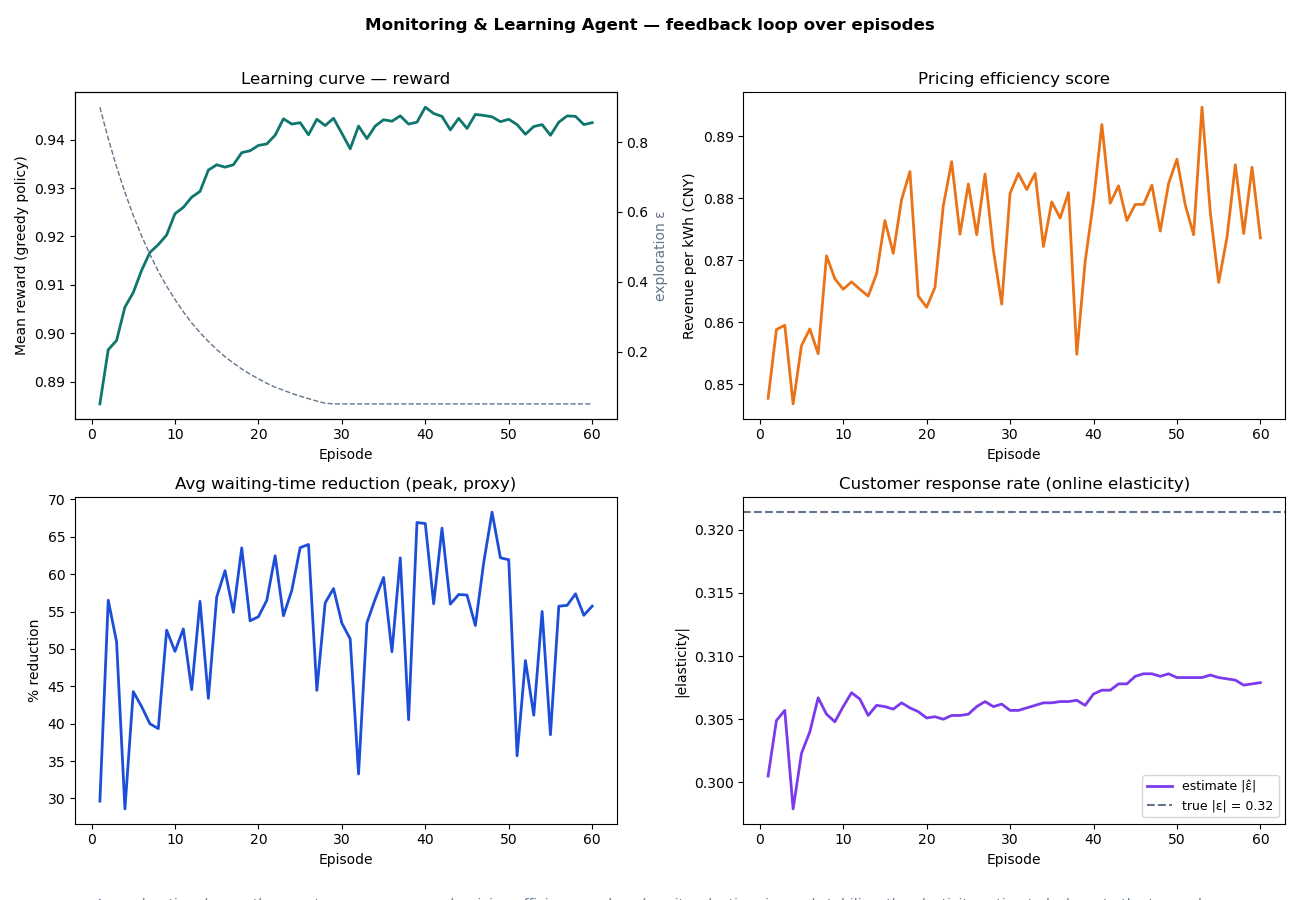

In [2]:
display(em[['episode','epsilon','composite_reward','pricing_efficiency',
            'avg_wait_reduction_pct','customer_response_rate']].iloc[[0,9,29,59]])
display(Image(C.FIG_DIR/'fig15_learning_curve.png'))

## What the agent learned, and how it compares
**Honest result:** under inelastic demand a myopic reward-maximizer learns to **surge the rare congested buckets and stay neutral elsewhere** — it does not discount (off-peak discounting is unprofitable short-run). This beats both the flat baseline and the Phase-4 fixed policy on revenue *and* congestion; off-peak uplift is the trade-off it forgoes.

,bucket,utilization_range,learned_multiplier,Q_value
0,0,"[0,0.15) very-low",1.0,0.8923
1,1,"[0.15,0.30) low",1.0,0.9716
2,2,"[0.30,0.80) mid",1.0,0.9004
3,3,"[0.80,0.90) high",1.6,0.9792
4,4,"[0.90,1.0] very-high",1.6,0.7611


,rev_gain_pct,avg_wait_reduction_pct,peak_reduction_pp,pricing_efficiency,offpeak_uplift_pct
flat_baseline,0.000,0.000,0.000,0.871,0.000
phase4_fixed(0.90/1.60),-0.255,43.851,2.587,0.868,0.818
learned_agent,0.656,57.548,6.211,0.879,0.000


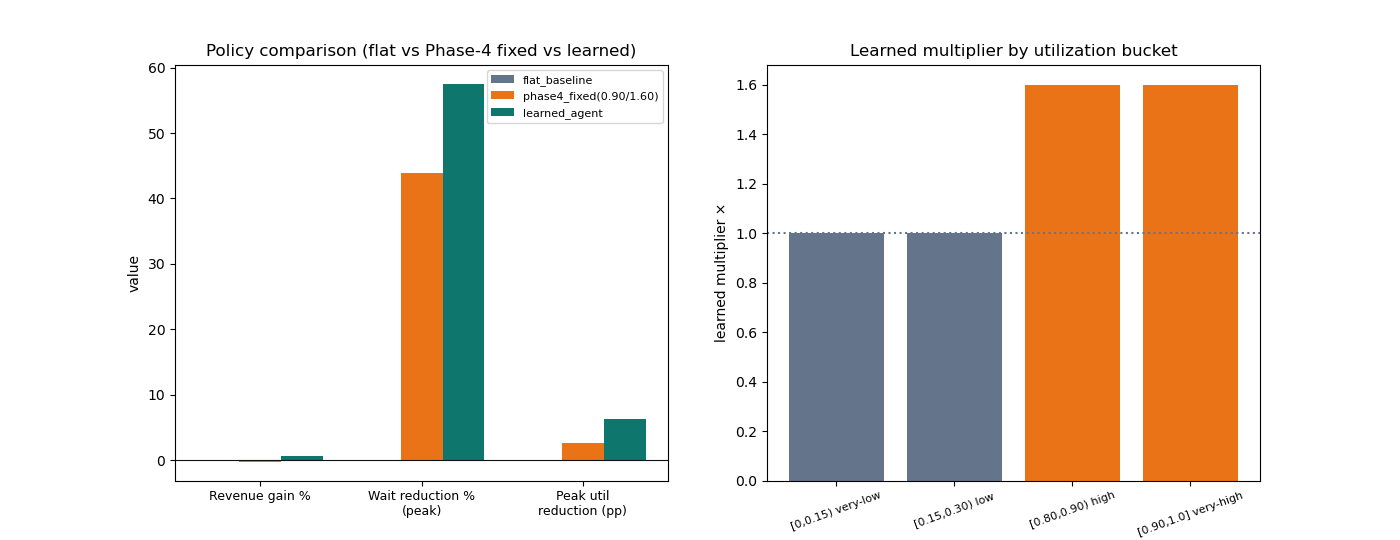

In [3]:
display(learned)
display(comp[['rev_gain_pct','avg_wait_reduction_pct','peak_reduction_pp',
              'pricing_efficiency','offpeak_uplift_pct']].round(3))
display(Image(C.FIG_DIR/'fig16_policy_comparison.png'))

---
**Phase 5 complete.** The feedback loop demonstrably improves pricing decisions over episodes and recovers the true demand response online. Remaining: Phase 6 (robustness + business/policy implications) and Phase 7 (deck).